This notebook installs necessary libraries for data analysis and machine learning, sets up Kaggle for dataset access, and lists available Kaggle datasets.


# Brain Tumor Classification using Deep Learning
SE4050 - Deep Learning Project
Team Members: Dhanithya Beligolla

Dataset: Brain Tumor MRI Images
Models: Custom CNN, VGG16, ResNet50, EfficientNetB0



## 1) COLAB & ENV SETUP

In [1]:

!nvidia-smi -L || true

# Quiet installs (tf-addons used for metrics later, imagehash used for duplicate checks)
!pip -q install tensorflow-addons imagehash imbalanced-learn scikit-plot > /dev/null

import os, random, numpy as np, tensorflow as tf, warnings
warnings.filterwarnings('ignore')

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPU 0: Tesla T4 (UUID: GPU-d493eeb8-bc78-f0f2-5783-988e0708a008)
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 2) Kaggle Setup & Dataset Download
We will download **Brain Tumor MRI Dataset (4 classes)** from Kaggle.  
**Instructions:**  
1. In Colab, go to **left sidebar → Files** and verify this notebook's working directory is `/content`.  
2. Run the cell below, then **upload your `kaggle.json`** (from Kaggle → *Account* → *Settings* → *Create New API Token*).  


In [2]:

from pathlib import Path
from google.colab import files

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

print("➡️ Please upload your kaggle.json in the next prompt.")
uploaded = files.upload()  # user uploads kaggle.json

if "kaggle.json" in uploaded:
    import shutil, stat
    shutil.move("kaggle.json", kaggle_dir/"kaggle.json")
    os.chmod(kaggle_dir/"kaggle.json", stat.S_IRUSR | stat.S_IWUSR)
    print("✅ kaggle.json installed.")
else:
    raise RuntimeError("kaggle.json not uploaded. Please rerun and upload.")


➡️ Please upload your kaggle.json in the next prompt.


Saving kaggle.json to kaggle.json
✅ kaggle.json installed.


In [3]:

!pip -q install kaggle > /dev/null

proj_root = Path("/content/brain_tumor_project")
data_root = proj_root/"data"
proj_root.mkdir(exist_ok=True, parents=True)

# Download the dataset
%cd /content
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content -o
!unzip -q -o /content/brain-tumor-mri-dataset.zip -d {str(data_root)}
!rm -f /content/brain-tumor-mri-dataset.zip

print("📂 Extracted to:", data_root)
!find {str(data_root)} -maxdepth 2 -type d -print


/content
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 98% 145M/149M [00:00<00:00, 1.51GB/s]
100% 149M/149M [00:00<00:00, 1.50GB/s]
📂 Extracted to: /content/brain_tumor_project/data
/content/brain_tumor_project/data
/content/brain_tumor_project/data/Testing
/content/brain_tumor_project/data/Testing/pituitary
/content/brain_tumor_project/data/Testing/notumor
/content/brain_tumor_project/data/Testing/glioma
/content/brain_tumor_project/data/Testing/meningioma
/content/brain_tumor_project/data/Training
/content/brain_tumor_project/data/Training/pituitary
/content/brain_tumor_project/data/Training/notumor
/content/brain_tumor_project/data/Training/glioma
/content/brain_tumor_project/data/Training/meningioma


## 3) Dataset Structure Overview

In [4]:

import os, pandas as pd

TRAIN_DIR = os.path.join(str(data_root), "Training")
TEST_DIR  = os.path.join(str(data_root), "Testing")
CLASSES   = ['glioma','meningioma','notumor','pituitary']

def count_images(root):
    rows = []
    for c in CLASSES:
        p = os.path.join(root, c)
        if os.path.exists(p):
            n = sum([1 for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            rows.append((c, n))
        else:
            rows.append((c, 0))
    return pd.DataFrame(rows, columns=["Class","Count"])

print("Train distribution:")
display(count_images(TRAIN_DIR))
print("Test distribution:")
display(count_images(TEST_DIR))


Train distribution:


,Class,Count
0,glioma,1321
1,meningioma,1339
2,notumor,1595
3,pituitary,1457


Test distribution:


,Class,Count
0,glioma,300
1,meningioma,306
2,notumor,405
3,pituitary,300



## 4) Robust Image Loader (Integrity Checks)
- Reads images, converts to RGB, resizes to `224×224`.  
- Skips unreadable/corrupted files.  
- Records problematic files for review.  


In [5]:

import cv2, numpy as np
from glob import glob

IMG_SIZE = (224, 224)

def load_images_from_dir(dir_path, classes):
    X, y, paths, bad_files = [], [], [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(dir_path, cname)
        if not os.path.exists(cdir):
            continue
        for fp in glob(os.path.join(cdir, "*")):
            if not fp.lower().endswith(('.png','.jpg','.jpeg')):
                continue
            try:
                img_bgr = cv2.imread(fp)
                if img_bgr is None:
                    bad_files.append(fp); continue
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                img_rgb = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
                X.append(img_rgb); y.append(ci); paths.append(fp)
            except Exception as e:
                bad_files.append(fp)
    return np.array(X), np.array(y), paths, bad_files

X_train_all, y_train_all, train_paths, bad_train = load_images_from_dir(TRAIN_DIR, CLASSES)
X_test_raw,  y_test_raw,  test_paths,  bad_test  = load_images_from_dir(TEST_DIR,  CLASSES)

print(f"Loaded TRAIN images: {X_train_all.shape} | bad files: {len(bad_train)}")
print(f"Loaded TEST images:  {X_test_raw.shape}  | bad files: {len(bad_test)}")

if bad_train or bad_test:
    print("⚠️ Bad files detected (first 10 shown):")
    print((bad_train + bad_test)[:10])


Loaded TRAIN images: (5712, 224, 224, 3) | bad files: 0
Loaded TEST images:  (1311, 224, 224, 3)  | bad files: 0



## 5) Duplicate Detection & Removal
We detect **exact duplicates** using perceptual hashing (average hash). Duplicates in **Training** are removed to avoid leakage and bias.


In [6]:
!pip install imagehash Pillow
import imagehash
from PIL import Image

def find_duplicates(paths):
    seen = {}
    dups = []
    for fp in paths:
        try:
            with Image.open(fp) as im:
                im = im.convert("RGB").resize((128,128), Image.BILINEAR)
                h = str(imagehash.average_hash(im))
            if h in seen:
                dups.append((fp, seen[h]))
            else:
                seen[h] = fp
        except Exception:
            # Skip unreadable in hashing step
            pass
    return dups

dups_train = find_duplicates(train_paths)
print(f"Found {len(dups_train)} potential duplicate pairs in TRAIN (show first 5):")
print(dups_train[:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.5 MB/s eta 0:00:00
Found 2642 potential duplicate pairs in TRAIN (show first 5):
[('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0199.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0276.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0245.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_1150.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0380.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0564.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0215.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_0214.jpg'), ('/content/brain_tumor_project/data/Training/glioma/Tr-gl_0270.jpg', '/content/brain_tumor_project/data/Training/glioma/Tr-gl_1150.jpg')]


In [7]:

# Build a keep/remove mask for training
to_remove = set([a for a,b in dups_train])  # remove the 'later' occurrence
keep_mask = np.array([p not in to_remove for p in train_paths])

X_train_all = X_train_all[keep_mask]
y_train_all = y_train_all[keep_mask]
train_paths = [p for i,p in enumerate(train_paths) if keep_mask[i]]

print("After duplicate removal -> TRAIN:", X_train_all.shape)


After duplicate removal -> TRAIN: (3070, 224, 224, 3)



## 6) Stratified Split (Training→Train/Val) & Preserve Official Test
We use **Training** for `train/val` (stratified, 85/15) and the dataset's official **Testing** as our `test` set.


In [8]:

from sklearn.model_selection import train_test_split
import pandas as pd

X_train, X_val, y_train, y_val, train_paths_final, val_paths = train_test_split(
    X_train_all, y_train_all, train_paths, test_size=0.15, random_state=SEED, stratify=y_train_all
)

X_test, y_test = X_test_raw, y_test_raw

def dist(y):
    import numpy as np, pandas as pd
    u, c = np.unique(y, return_counts=True)
    return pd.DataFrame({'Class':[CLASSES[i] for i in u], 'Count':c})

print("Train dist:"); display(dist(y_train))
print("Val dist:");   display(dist(y_val))
print("Test dist:");  display(dist(y_test))

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train dist:


,Class,Count
0,glioma,697
1,meningioma,715
2,notumor,415
3,pituitary,782


Val dist:


,Class,Count
0,glioma,123
1,meningioma,127
2,notumor,73
3,pituitary,138


Test dist:


,Class,Count
0,glioma,300
1,meningioma,306
2,notumor,405
3,pituitary,300


Shapes -> Train: (2609, 224, 224, 3) Val: (461, 224, 224, 3) Test: (1311, 224, 224, 3)



## 7) Preprocessing Pipelines & Class Weights
- **Normalization**: scale to `[0,1]` now (transfer-learning specific preprocessing can be added later per backbone).  
- **Class weights** computed from the training distribution (used during training phase, not here).  


In [9]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Normalize to [0,1] for now (generic)
X_train_f = (X_train.astype('float32')/255.0)
X_val_f   = (X_val.astype('float32')/255.0)
X_test_f  = (X_test.astype('float32')/255.0)

# Compute class weights on train
classes_idx = np.arange(len(CLASSES))
cw = compute_class_weight(class_weight='balanced', classes=classes_idx, y=y_train)
class_weights = {i: float(w) for i,w in enumerate(cw)}
class_weights


{0: 0.9357962697274032,
 1: 0.9122377622377622,
 2: 1.5716867469879519,
 3: 0.834079283887468}


## 8) Visual Sanity Checks
We confirm shapes, ranges, and sample visuals **after preprocessing**.


Ranges -> Train min/max: 0.0 1.0
Ranges -> Val   min/max: 0.0 1.0
Ranges -> Test  min/max: 0.0 1.0


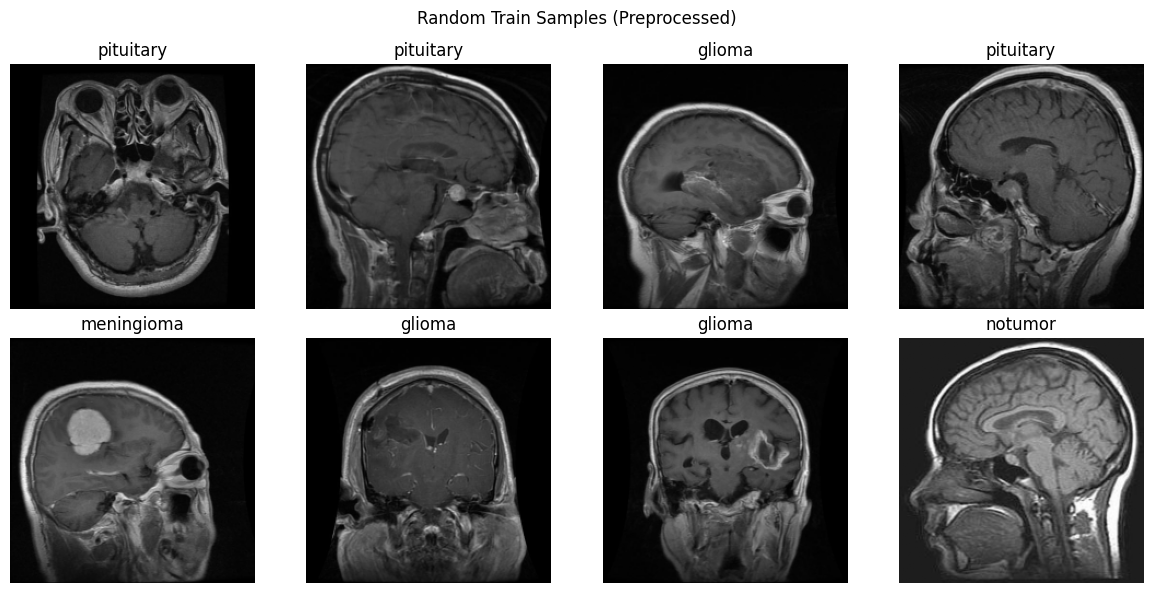

In [10]:

import matplotlib.pyplot as plt
import numpy as np

print("Ranges -> Train min/max:", X_train_f.min(), X_train_f.max())
print("Ranges -> Val   min/max:", X_val_f.min(), X_val_f.max())
print("Ranges -> Test  min/max:", X_test_f.min(), X_test_f.max())

# Show a grid of random training samples
idxs = np.random.choice(len(X_train_f), size=8, replace=False)
plt.figure(figsize=(12,6))
for i,ix in enumerate(idxs):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train_f[ix])
    plt.title(CLASSES[y_train[ix]])
    plt.axis('off')
plt.suptitle("Random Train Samples (Preprocessed)")
plt.tight_layout(); plt.show()



## 9) Save Cleaned Splits (Optional)
Saves NumPy arrays so teammates can load the same cleaned data without re-running integrity checks.


In [13]:

import numpy as np, os
clean_dir = os.path.join(str(proj_root), "clean_np")
os.makedirs(clean_dir, exist_ok=True)

np.save(os.path.join(clean_dir, "X_train.npy"), X_train_f)
np.save(os.path.join(clean_dir, "y_train.npy"), y_train)
np.save(os.path.join(clean_dir, "X_val.npy"),   X_val_f)
np.save(os.path.join(clean_dir, "y_val.npy"),   y_val)
np.save(os.path.join(clean_dir, "X_test.npy"),  X_test_f)
np.save(os.path.join(clean_dir, "y_test.npy"),  y_test)

with open(os.path.join(clean_dir, "class_weights.json"), "w") as f:
    import json; json.dump(class_weights, f, indent=2)

print("📦 Saved cleaned arrays to:", clean_dir)
!ls -lh {clean_dir}


📦 Saved cleaned arrays to: /content/brain_tumor_project/clean_np
total 2.5G
-rw-r--r-- 1 root root  109 Oct 12 12:21 class_weights.json
-rw-r--r-- 1 root root 753M Oct 12 12:21 X_test.npy
-rw-r--r-- 1 root root 1.5G Oct 12 12:21 X_train.npy
-rw-r--r-- 1 root root 265M Oct 12 12:21 X_val.npy
-rw-r--r-- 1 root root  11K Oct 12 12:21 y_test.npy
-rw-r--r-- 1 root root  21K Oct 12 12:21 y_train.npy
-rw-r--r-- 1 root root 3.8K Oct 12 12:21 y_val.npy


In [14]:
# device_check.py
import sys, platform, os
import torch
import timm
import numpy as np

print("Python:", sys.version.splitlines()[0])
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("NumPy version:", np.__version__)
print("PyTorch version:", torch.__version__)
print("timm version:", getattr(timm, '__version__', 'timm not found'))

# Torch device info
if torch.cuda.is_available():
    print("CUDA available: True")
    print("CUDA devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"  [{i}] Name:", torch.cuda.get_device_name(i))
        print(f"      Capability:", torch.cuda.get_device_capability(i))
        print(f"      Allocated memory (MB):", round(torch.cuda.memory_allocated(i)/1024**2,2))
else:
    print("CUDA available: False")

# Try DirectML (Windows) detection
try:
    import importlib
    if importlib.util.find_spec("torch_directml") is not None:
        print("torch-directml installed: True")
    else:
        print("torch-directml installed: False")
except Exception:
    print("torch-directml detection error")

# Quick RAM check
try:
    import psutil
    mem = psutil.virtual_memory()
    print("Total RAM (GB):", round(mem.total/1024**3,2))
except Exception:
    print("psutil not installed; skip RAM check (optional: pip install psutil)")

print("\\n--- Quick test: instantiate EfficientNet-B3 (without weights) ---")
try:
    m = timm.create_model('efficientnet_b3', pretrained=False, num_classes=4)
    print("EfficientNet-B3 model created OK.")
except Exception as e:
    print("EfficientNet-B3 creation error:", e)


Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
Platform: Linux-6.6.97+-x86_64-with-glibc2.35
Processor: x86_64
NumPy version: 2.0.2
PyTorch version: 2.8.0+cu126
timm version: 1.0.20
CUDA available: True
CUDA devices: 1
  [0] Name: Tesla T4
      Capability: (7, 5)
      Allocated memory (MB): 0.0
torch-directml installed: False
Total RAM (GB): 12.67
\n--- Quick test: instantiate EfficientNet-B3 (without weights) ---
EfficientNet-B3 model created OK.


In [15]:
# step2_efficientnet_smoketest.py
import os, time
import numpy as np
import torch
import timm
import cv2
from pathlib import Path

# CONFIG (change if you used other paths)
DATA_ROOT = Path("./brain_tumor_project/clean_np")  # preferred place if you saved cleaned arrays
ALT_TRAIN_DIR = Path("./brain_tumor_project/data/Training")  # fallback raw images

IMG_SIZE = 224
BATCH = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1) Try to load pre-saved cleaned numpy arrays (fast)
X = None
try:
    arr_path = DATA_ROOT / "X_train.npy"
    if arr_path.exists():
        print("Loading cleaned arrays from:", arr_path)
        X_all = np.load(str(arr_path))
        # take first BATCH images (already normalized if from earlier notebook)
        X = X_all[:BATCH]
        # ensure shape HWC and 0..1 floats
        if X.dtype != np.float32:
            X = X.astype("float32") / 255.0
        if X.shape[1] != IMG_SIZE or X.shape[2] != IMG_SIZE:
            # resize
            X = np.stack([cv2.resize((img*255).astype('uint8'), (IMG_SIZE,IMG_SIZE)).astype('float32')/255.0 if img.max()<=1.0 else cv2.resize(img, (IMG_SIZE,IMG_SIZE)).astype('float32')/255.0 for img in X])
        print("Loaded from numpy, X shape:", X.shape)
except Exception as e:
    print("No cleaned numpy load:", e)

# 2) Fallback: load a few raw images from Training folder
if X is None:
    imgs = []
    if ALT_TRAIN_DIR.exists():
        print("Falling back to raw images at:", ALT_TRAIN_DIR)
        # search classes
        for cls in os.listdir(str(ALT_TRAIN_DIR)):
            cls_dir = ALT_TRAIN_DIR/cls
            if not cls_dir.is_dir(): continue
            for i, f in enumerate(sorted(os.listdir(cls_dir))[:2]):  # take 2 per class until BATCH
                fp = cls_dir / f
                try:
                    im = cv2.imread(str(fp))
                    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
                    im = cv2.resize(im, (IMG_SIZE, IMG_SIZE))
                    imgs.append(im.astype('float32')/255.0)
                    if len(imgs) >= BATCH: break
                except Exception:
                    pass
            if len(imgs) >= BATCH: break
    if len(imgs) > 0:
        X = np.stack(imgs)
        print("Loaded raw images, X shape:", X.shape)
    else:
        # final fallback: random tensor
        print("No images found — using random tensor fallback.")
        X = np.random.rand(BATCH, IMG_SIZE, IMG_SIZE, 3).astype('float32')

# 3) Convert to torch CHW and to device
X_t = torch.from_numpy(X).permute(0,3,1,2).to(device)

# 4) Instantiate EfficientNet-B3 (pretrained)
print("Creating EfficientNet-B3 (may download weights the first time)...")
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=4)
model = model.to(device)
model.eval()

# 5) Forward pass (timing)
with torch.no_grad():
    t0 = time.time()
    out = model(X_t)
    t1 = time.time()
    print("Forward pass done. Output shape:", out.shape)
    print("Elapsed time (s) for batch of", X_t.shape[0], ":", round(t1-t0,4))

# 6) Print a tiny summary
print("Model params (millions):", sum(p.numel() for p in model.parameters())/1e6)
print("Sample softmax (first row):", torch.softmax(out, dim=1)[0].cpu().numpy())


Device: cuda
Loading cleaned arrays from: brain_tumor_project/clean_np/X_train.npy
Loaded from numpy, X shape: (8, 224, 224, 3)
Creating EfficientNet-B3 (may download weights the first time)...


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Forward pass done. Output shape: torch.Size([8, 4])
Elapsed time (s) for batch of 8 : 5.3207
Model params (millions): 10.70238
Sample softmax (first row): [0.03785877 0.8715022  0.05312194 0.03751707]


Train: (2609, 224, 224, 3) Val: (461, 224, 224, 3) Test: (1311, 224, 224, 3)
Batch imgs shape: torch.Size([32, 3, 224, 224]) labels shape: torch.Size([32])


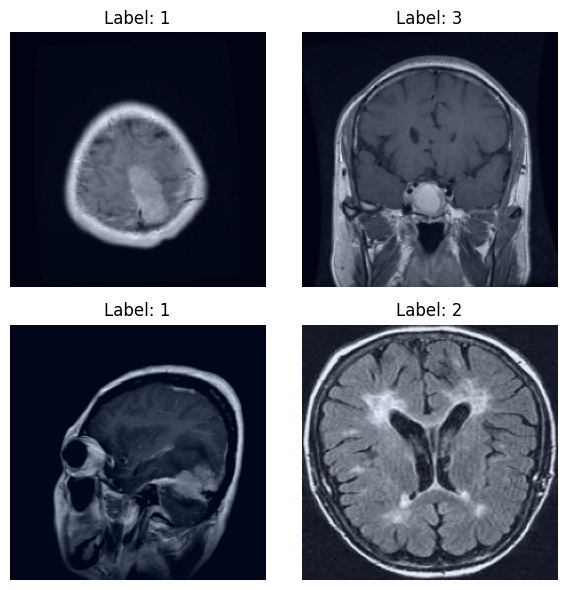

In [16]:
# step3_dataloaders.py
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

IMG_SIZE = 224          # can raise to 300 if VRAM allows
BATCH_SIZE = 32         # tune per GPU memory
NUM_WORKERS = 4

# ---- 1. Load saved arrays ----
X_train = np.load("brain_tumor_project/clean_np/X_train.npy")
y_train = np.load("brain_tumor_project/clean_np/y_train.npy")
X_val   = np.load("brain_tumor_project/clean_np/X_val.npy")
y_val   = np.load("brain_tumor_project/clean_np/y_val.npy")
X_test  = np.load("brain_tumor_project/clean_np/X_test.npy")
y_test  = np.load("brain_tumor_project/clean_np/y_test.npy")

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ---- 2. Define augmentations ----
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])
val_aug = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

# ---- 3. Custom Dataset class ----
class BrainDataset(Dataset):
    def __init__(self, X, y, aug=None):
        self.X = X.astype("float32")
        self.y = y.astype("int64")
        self.aug = aug
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        if img.max() <= 1: img = img*255
        img = img.astype("uint8")
        if self.aug:
            img = self.aug(image=img)["image"]
        return img, label

train_ds = BrainDataset(X_train, y_train, aug=train_aug)
val_ds   = BrainDataset(X_val, y_val, aug=val_aug)
test_ds  = BrainDataset(X_test, y_test, aug=val_aug)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ---- 4. Quick sanity check ----
imgs, labels = next(iter(train_loader))
print("Batch imgs shape:", imgs.shape, "labels shape:", labels.shape)

# visualize 4 samples
plt.figure(figsize=(6,6))
for i in range(4):
    img = imgs[i].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max()-img.min())
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [17]:
# step4_model_build.py
import torch
import torch.nn as nn
import timm

NUM_CLASSES = 4
LEARNING_RATE = 1e-4  # 🔧 can try 1e-3 or 5e-5 for fine-tuning
DROPOUT_RATE = 0.4    # 🔧 change 0.3–0.5 for regularization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- 1. Create EfficientNet-B3 backbone ---
model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=DROPOUT_RATE
)

# Optional: unfreeze last few blocks for fine-tuning
for name, param in model.named_parameters():
    param.requires_grad = False
for name, param in list(model.named_parameters())[-50:]:  # 🔧 unfreeze deeper layers
    param.requires_grad = True

# --- 2. Move to device & print summary ---
model = model.to(device)
print("Model built successfully with", sum(p.numel() for p in model.parameters())/1e6, "M params")

# --- 3. Define loss & optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("✅ Model, loss, optimizer, scheduler ready.")


Using device: cuda
Model built successfully with 10.70238 M params
✅ Model, loss, optimizer, scheduler ready.



===== Epoch 1/25 =====


Train Loss 1.7206 | Train Acc 0.6090 | Val Loss 707.8130 | Val Acc 0.7918
✅ Saved new best model (Val Acc: 0.7918)

===== Epoch 2/25 =====


Train Loss 0.6802 | Train Acc 0.8053 | Val Loss 67.5354 | Val Acc 0.8416
✅ Saved new best model (Val Acc: 0.8416)

===== Epoch 3/25 =====


Train Loss 0.5001 | Train Acc 0.8406 | Val Loss 65.5814 | Val Acc 0.8460
✅ Saved new best model (Val Acc: 0.8460)

===== Epoch 4/25 =====


Train Loss 0.4024 | Train Acc 0.8678 | Val Loss 46.3685 | Val Acc 0.8872
✅ Saved new best model (Val Acc: 0.8872)

===== Epoch 5/25 =====


...

Train Loss 0.1306 | Train Acc 0.9559 | Val Loss 168.3532 | Val Acc 0.9197
✅ Saved new best model (Val Acc: 0.9197)

===== Epoch 22/25 =====


Train Loss 0.0997 | Train Acc 0.9651 | Val Loss 54.9129 | Val Acc 0.9132

===== Epoch 23/25 =====


Train Loss 0.1089 | Train Acc 0.9651 | Val Loss 498.8232 | Val Acc 0.9176

===== Epoch 24/25 =====


Train Loss 0.0956 | Train Acc 0.9674 | Val Loss 247.2552 | Val Acc 0.9262
✅ Saved new best model (Val Acc: 0.9262)

===== Epoch 25/25 =====


Train Loss 0.0859 | Train Acc 0.9732 | Val Loss 2050.4097 | Val Acc 0.9197


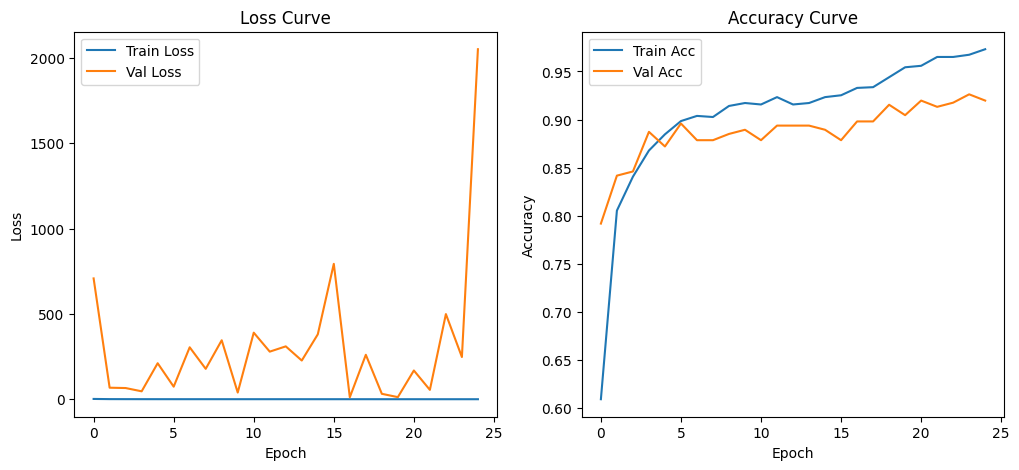

Best validation accuracy: 0.9262


In [18]:
# step5_train_efficientnetb3.py
import torch, time
from tqdm import tqdm
import matplotlib.pyplot as plt

EPOCHS = 25        # 🔧 increase to 40–60 for stronger training
SAVE_PATH = "best_efficientnetB3_brain.pth"

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")
    model.train()
    running_loss, correct = 0.0, 0
    for imgs, labels in tqdm(train_loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ---- Validation ----
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="Validating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # ---- Save best checkpoint ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"✅ Saved new best model (Val Acc: {val_acc:.4f})")

# ---- Training curves ----
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curve")
plt.show()

print(f"Best validation accuracy: {best_val_acc:.4f}")



=== Test Metrics ===
Accuracy : 0.9458
Precision: 0.9457
Recall   : 0.9458
F1-score : 0.9456

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9159    0.9433    0.9294       300
  meningioma     0.9116    0.8758    0.8933       306
     notumor     0.9729    0.9753    0.9741       405
   pituitary     0.9735    0.9800    0.9767       300

    accuracy                         0.9458      1311
   macro avg     0.9435    0.9436    0.9434      1311
weighted avg     0.9457    0.9458    0.9456      1311



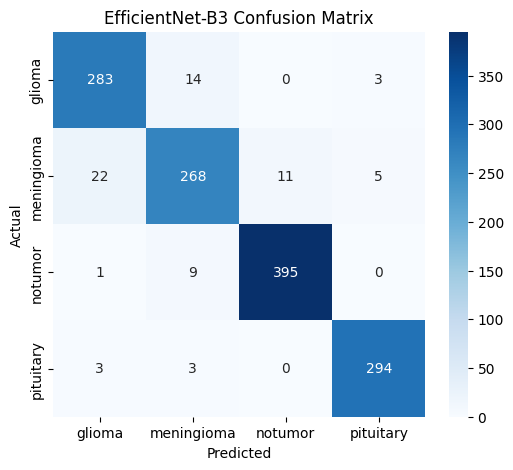

In [19]:
# step6_evaluate_efficientnetb3.py
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# reload best checkpoint
model.load_state_dict(torch.load("best_efficientnetB3_brain.pth", map_location=device))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print("\n=== Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet-B3 Confusion Matrix")
plt.show()


In [31]:
import shutil

# Compress the .pth file into a zip
shutil.make_archive("best_efficientnetB3_brain", "zip", root_dir=".", base_dir="best_efficientnetB3_brain.pth")

print("✅ Model zipped as best_efficientnetB3_brain.zip")


✅ Model zipped as best_efficientnetB3_brain.zip


In [33]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [34]:
import shutil

# zip the model
shutil.make_archive("/content/drive/MyDrive/best_efficientnetB3_brain", "zip", root_dir=".", base_dir="best_efficientnetB3_brain.pth")

print("✅ Saved best_efficientnetB3_brain.zip to your Google Drive")


✅ Saved best_efficientnetB3_brain.zip to your Google Drive
